# Analyse des données énergétiques

Ce notebook contient l'analyse des données énergétiques normalisées et transformées.

## 1. Configuration et imports

In [134]:
import os
import json
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import boxcox, probplot, fisher_exact, chi2_contingency, shapiro, t, normaltest, jarque_bera, anderson, skew, kurtosis, pearsonr

from scipy.special import inv_boxcox

from sklearn.model_selection import train_test_split, cross_val_predict, RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer,PowerTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression, RidgeCV, HuberRegressor
from sklearn.utils import resample
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble            import BaggingRegressor



import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import outlier_test, OLSInfluence

import openai
from IPython.display import display, Markdown

import matplotlib.pyplot as plt

from dotenv import load_dotenv

import pprint

# Configuration des chemins
DATA_DIR = os.path.join('..', 'data')
NORMALIZED_DIR = os.path.join(DATA_DIR, 'normalized_csv')
TRANSFORMED_DIR = os.path.join(DATA_DIR, 'transformed_data')

# Afficher les chemins
print("DATA_DIR:", os.path.abspath(DATA_DIR))
print("NORMALIZED_DIR:", os.path.abspath(NORMALIZED_DIR))
print("TRANSFORMED_DIR:", os.path.abspath(TRANSFORMED_DIR))

# Vérifier l'existence des répertoires
print("Vérification des répertoires:")
print("DATA_DIR existe:", os.path.exists(DATA_DIR))
print("NORMALIZED_DIR existe:", os.path.exists(NORMALIZED_DIR))
print("TRANSFORMED_DIR existe:", os.path.exists(TRANSFORMED_DIR))

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')  # Style par défaut de matplotlib
sns.set_theme()  # Style par défaut de seaborn

DATA_DIR: C:\dauphine_projects\Conso_Energy\data
NORMALIZED_DIR: C:\dauphine_projects\Conso_Energy\data\normalized_csv
TRANSFORMED_DIR: C:\dauphine_projects\Conso_Energy\data\transformed_data
Vérification des répertoires:
DATA_DIR existe: True
NORMALIZED_DIR existe: True
TRANSFORMED_DIR existe: True


## 2. Chargement des données

In [11]:
# Charger les données avec les bons paramètres
def load_data(directory):
    """
    Charge tous les fichiers CSV d'un répertoire dans un dictionnaire de DataFrames.
    
    Args:
        directory (str): Chemin du répertoire contenant les fichiers CSV
        
    Returns:
        dict: Dictionnaire avec les noms de fichiers comme clés et les DataFrames comme valeurs
    """
    data = {}
    for file in os.listdir(directory):
        if file.endswith('.csv'):
            file_path = os.path.join(directory, file)
            # Utiliser sep=';' et decimal=',' pour le format français
            data[file] = pd.read_csv(file_path, sep=';', decimal=',')
    return data

# Charger les données
print("Chargement des données :")
normalized_data = load_data(NORMALIZED_DIR)
transformed_data = load_data(TRANSFORMED_DIR)

# Afficher les premières lignes des données chargées
for file_name, df in normalized_data.items():
    print(f"Données brutes de {file_name} :")
    display(df.head())
    print("Types des colonnes :")
    display(df.dtypes)

Chargement des données :
Données brutes de normalized_ENB2012_data.csv :


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Types des colonnes :


relative_compactness    float64
surface_area            float64
wall_area               float64
roof_area               float64
overall_height          float64
orientation               int64
glazing_area            float64
glazing_distribution      int64
heating_load            float64
cooling_load            float64
dtype: object

## 3. Analyse des valeurs manquantes

In [14]:
def analyze_missing_values(df):
    """
    Analyse les valeurs manquantes dans un DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame à analyser
        
    Returns:
        dict: Dictionnaire contenant les statistiques des valeurs manquantes
    """
    # Calcul du nombre total de lignes
    total_rows = len(df)
    
    # Calcul des lignes avec au moins une valeur manquante
    rows_with_missing = df.isnull().any(axis=1).sum()
    
    # Calcul des statistiques par colonne
    missing_stats = df.isnull().sum()
    missing_percentages = (missing_stats / total_rows * 100).round(2)
    
    # Colonnes avec au moins une valeur manquante
    columns_with_missing = missing_stats[missing_stats > 0].index.tolist()
    
    return {
        'total_rows': total_rows,
        'rows_with_missing': rows_with_missing,
        'percentage_rows_with_missing': (rows_with_missing / total_rows * 100).round(2),
        'columns_with_missing': columns_with_missing,
        'missing_stats': pd.DataFrame({
            'missing_count': missing_stats,
            'missing_percentage': missing_percentages
        }).loc[columns_with_missing]
    }
    
def display_missing_values_analysis(data_dict, title):
    """
    Affiche l'analyse des valeurs manquantes pour un ensemble de DataFrames.
    
    Args:
        data_dict (dict): Dictionnaire de DataFrames
        title (str): Titre de l'analyse
    """
    print(f"=== {title} === \n")
    
    for file_name, df in data_dict.items():
        print(f"Analyse pour {file_name}:")
        missing_analysis = analyze_missing_values(df)
        
        print(f"Nombre total de lignes: {missing_analysis['total_rows']}")
        print(f"Lignes avec valeurs manquantes: {missing_analysis['rows_with_missing']} ({missing_analysis['percentage_rows_with_missing']}%)")
        
        if missing_analysis['columns_with_missing']:
            print("Colonnes avec valeurs manquantes:")
            print(missing_analysis['missing_stats'])
        else:
            print("Aucune valeur manquante dans ce fichier.")
        
        print("\n" + "="*50 + "\n")

In [16]:
# Analyse des données normalisées
display_missing_values_analysis(normalized_data, "Données normalisées")

# Analyse des données transformées
display_missing_values_analysis(transformed_data, "Données transformées")

=== Données normalisées === 

Analyse pour normalized_ENB2012_data.csv:
Nombre total de lignes: 768
Lignes avec valeurs manquantes: 0 (0.0%)
Aucune valeur manquante dans ce fichier.


=== Données transformées === 

Analyse pour transformed_normalized_ENB2012_data.csv:
Nombre total de lignes: 768
Lignes avec valeurs manquantes: 0 (0.0%)
Aucune valeur manquante dans ce fichier.




## 4. Configuration des colonnes

In [19]:
# Configuration des colonnes
column_config = {
    'X1': {'name': 'relative_compactness', 'type': 'numeric', 'prefix': 'f_'},
    'X2': {'name': 'surface_area', 'type': 'numeric', 'prefix': 'f_'},
    'X3': {'name': 'wall_area', 'type': 'numeric', 'prefix': 'f_'},
    'X4': {'name': 'roof_area', 'type': 'numeric', 'prefix': 'f_'},
    'X5': {'name': 'overall_height', 'type': 'numeric', 'prefix': 'f_'},
    'X6': {'name': 'orientation', 'type': 'categorical', 'prefix': 'f_'},
    'X7': {'name': 'glazing_area', 'type': 'numeric', 'prefix': 'f_'},
    'X8': {'name': 'glazing_distribution', 'type': 'categorical', 'prefix': 'f_'},
    'Y1': {'name': 'heating_load', 'type': 'numeric', 'prefix': 'l_'},
    'Y2': {'name': 'cooling_load', 'type': 'numeric', 'prefix': 'l_'}
}

# Créer un DataFrame pour l'affichage
config_df = pd.DataFrame([
    {
        'Code': code,
        'Nom': config['name'],
        'Nom avec préfixe': f"{config['prefix']}{config['name']}",
        'Type': config['type']
    }
    for code, config in column_config.items()
])

# Afficher le tableau
print("Configuration des colonnes :")
display(config_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
    .hide(axis='index')
)

Configuration des colonnes :


Code,Nom,Nom avec préfixe,Type
X1,relative_compactness,f_relative_compactness,numeric
X2,surface_area,f_surface_area,numeric
X3,wall_area,f_wall_area,numeric
X4,roof_area,f_roof_area,numeric
X5,overall_height,f_overall_height,numeric
X6,orientation,f_orientation,categorical
X7,glazing_area,f_glazing_area,numeric
X8,glazing_distribution,f_glazing_distribution,categorical
Y1,heating_load,l_heating_load,numeric
Y2,cooling_load,l_cooling_load,numeric


## 5. Conversion des colonnes

In [22]:
# Fonction pour convertir les colonnes selon leur type
def convert_columns(df, column_config):
    """
    Convertit les colonnes selon leur type et applique les préfixes appropriés.
    
    Args:
        df (pd.DataFrame): DataFrame à convertir
        column_config (dict): Configuration des colonnes
        
    Returns:
        pd.DataFrame: DataFrame converti
    """
    # Créer une copie du DataFrame
    df_converted = df.copy()
    
    # Dictionnaire pour mapper les noms originaux aux noms avec préfixes
    column_mapping = {}
    
    # Parcourir la configuration et convertir les colonnes
    for code, config in column_config.items():
        original_name = config['name']
        new_name = f"{config['prefix']}{original_name}"
        
        if original_name in df_converted.columns:
            # Convertir selon le type
            if config['type'] == 'numeric':
                df_converted[original_name] = pd.to_numeric(df_converted[original_name], errors='coerce')
            elif config['type'] == 'categorical':
                df_converted[original_name] = df_converted[original_name].astype('category')
            
            # Enregistrer le mapping
            column_mapping[original_name] = new_name
    
    # Renommer les colonnes avec les préfixes
    df_converted = df_converted.rename(columns=column_mapping)
    
    return df_converted

# Convertir les données normalisées
print("Conversion des données normalisées :")
normalized_data_converted = {}
for file_name, df in normalized_data.items():
    print(f"Traitement du fichier {file_name}:")
    df_converted = convert_columns(df, column_config)
    normalized_data_converted[file_name] = df_converted
    print("Colonnes converties :")
    display(df_converted.head())
    print("Types des colonnes après conversion :")
    display(df_converted.dtypes)

Conversion des données normalisées :
Traitement du fichier normalized_ENB2012_data.csv:
Colonnes converties :


,f_relative_compactness,f_surface_area,f_wall_area,f_roof_area,f_overall_height,f_orientation,f_glazing_area,f_glazing_distribution,l_heating_load,l_cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Types des colonnes après conversion :


f_relative_compactness     float64
f_surface_area             float64
f_wall_area                float64
f_roof_area                float64
f_overall_height           float64
f_orientation             category
f_glazing_area             float64
f_glazing_distribution    category
l_heating_load             float64
l_cooling_load             float64
dtype: object

## 6. Analyse des corrélations

Analyse du fichier normalized_ENB2012_data.csv:
  Colonnes numériques trouvées: 8
Matrice de corrélation pour normalized_ENB2012_data.csv:
                        f_relative_compactness  f_surface_area   f_wall_area  \
f_relative_compactness            1.000000e+00   -9.919015e-01 -2.037817e-01   
f_surface_area                   -9.919015e-01    1.000000e+00  1.955016e-01   
f_wall_area                      -2.037817e-01    1.955016e-01  1.000000e+00   
f_roof_area                      -8.688234e-01    8.807195e-01 -2.923165e-01   
f_overall_height                  8.277473e-01   -8.581477e-01  2.809757e-01   
f_glazing_area                   -2.960552e-15    3.636925e-15 -8.567455e-17   
l_heating_load                    6.222719e-01   -6.581199e-01  4.556714e-01   
l_cooling_load                    6.343391e-01   -6.729989e-01  4.271170e-01   

                         f_roof_area  f_overall_height  f_glazing_area  \
f_relative_compactness -8.688234e-01      8.277473e-01   -2.960552

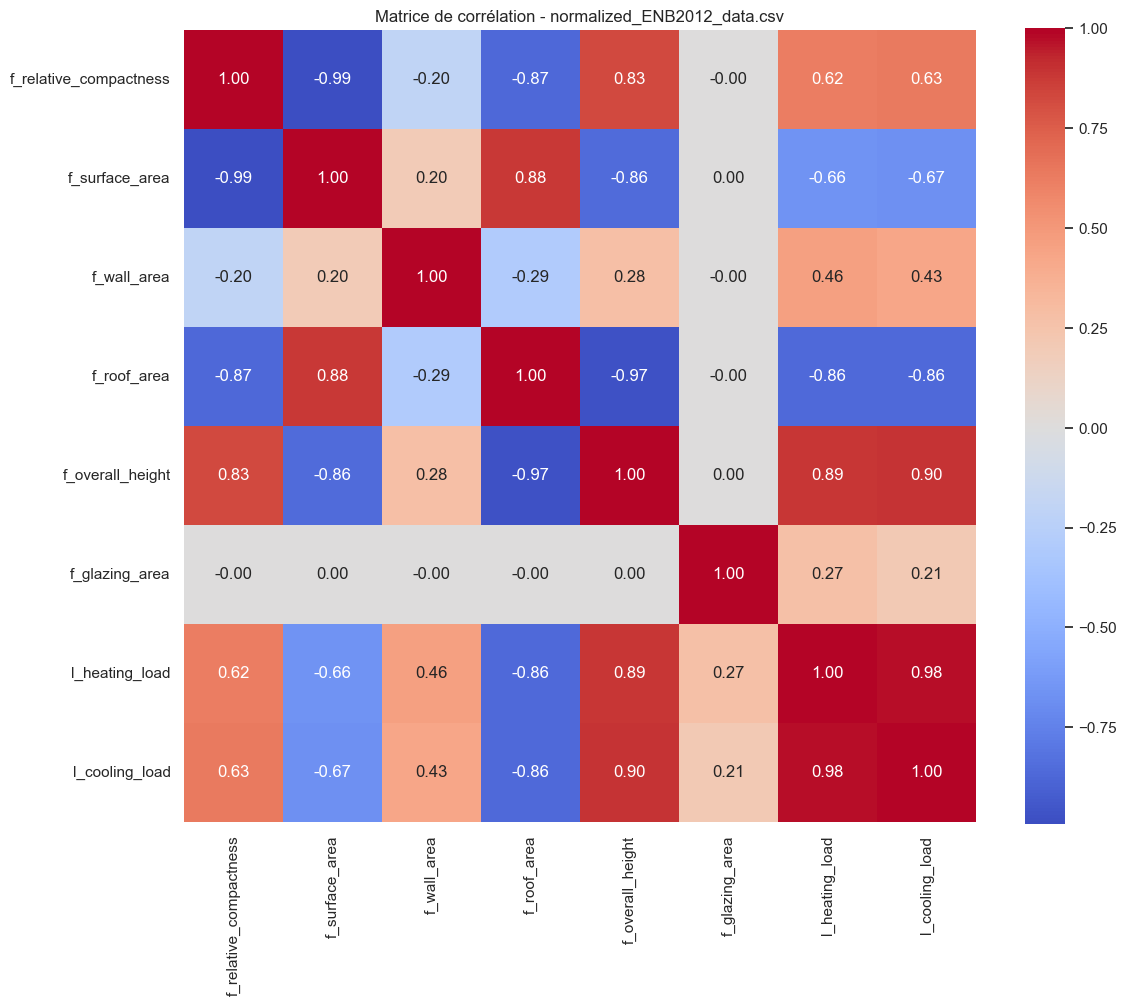

In [25]:
# Fonction pour créer la matrice de corrélation
def create_correlation_matrix(data_dict):
    """
    Crée une matrice de corrélation pour chaque DataFrame dans le dictionnaire.
    
    Args:
        data_dict (dict): Dictionnaire de DataFrames
        
    Returns:
        dict: Dictionnaire contenant les matrices de corrélation
    """
    correlation_matrices = {}
    
    for file_name, df in data_dict.items():
        print(f"Analyse du fichier {file_name}:")
        
        # Vérifier si le DataFrame est vide
        if df.empty:
            print(f"  Attention: Le DataFrame {file_name} est vide!")
            continue
            
        # Sélectionner uniquement les colonnes numériques
        numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
        
        # Vérifier s'il y a des colonnes numériques
        if len(numeric_cols) == 0:
            print(f"  Attention: Aucune colonne numérique trouvée dans {file_name}!")
            print("  Types de colonnes présents:", df.dtypes.unique())
            continue
            
        print(f"  Colonnes numériques trouvées: {len(numeric_cols)}")
        
        # Créer la matrice de corrélation
        corr_matrix = df[numeric_cols].corr()
        
        correlation_matrices[file_name] = corr_matrix
    
    return correlation_matrices

# Créer les matrices de corrélation pour les données normalisées converties
correlation_matrices = create_correlation_matrix(normalized_data_converted)

# Afficher les matrices de corrélation
for file_name, corr_matrix in correlation_matrices.items():
    print(f"Matrice de corrélation pour {file_name}:")
    print(corr_matrix)
    
    # Créer un heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                fmt='.2f',
                square=True)
    plt.title(f'Matrice de corrélation - {file_name}')
    plt.tight_layout()
    plt.show()

## 7. Test d'indépendance des variables catégorielles

### Démarche d'analyse

Pour tester l'indépendance entre les features catégorielles (f_orientation et f_glazing_distribution), nous utilisons :

- **Test exact de Fisher** :
  * H0 : Les variables sont indépendantes
  * H1 : Il existe une dépendance entre les variables
  * Interprétation : Si p-value < 0.05, on rejette H0 et on conclut à une dépendance entre les variables


In [28]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency

def test_categorical_independence(df, var1, var2, alpha=0.05):
    """
    Teste l'indépendance entre deux variables catégorielles en choisissant :
      - Fisher exact si table 2×2
      - Sinon Chi² d'indépendance + Cramér's V

    Args:
        df (pd.DataFrame): DataFrame contenant les données
        var1 (str): Nom de la première variable catégorielle
        var2 (str): Nom de la deuxième variable catégorielle
        alpha (float): Seuil de signification (par défaut 0.05)
    """
    print(f"=== Indépendance entre {var1} et {var2} ===")
    # Table de contingence
    contingency = pd.crosstab(df[var1], df[var2])
    display(contingency)

    # Cas 2×2 → Fisher
    if contingency.shape == (2, 2):
        odds_ratio, p_value = fisher_exact(contingency)
        print(f"Test exact de Fisher : p-value = {p_value:.4f}, odds ratio = {odds_ratio:.2f}")
        interpr = "→ dépendance" if p_value < alpha else "→ indépendance"
        print(f"Interprétation (α={alpha}): {interpr}")
        return

    # Sinon → Chi²
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi² = {chi2:.2f}, ddl = {dof}, p-value = {p:.4f}")

    # Vérifier les effectifs attendus
    low_exp = (expected < 5).sum()
    total = expected.size
    if low_exp / total > 0.2:
        print(f"⚠️ {low_exp}/{total} cases ont un effectif attendu <5 → conditions du Chi² non respectées")

    # Taille d'effet : Cramér's V
    n = contingency.values.sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    print(f"Cramér’s V = {cramers_v:.3f}")

    interpr = "→ dépendance" if p < alpha else "→ indépendance"
    print(f"Interprétation (α={alpha}): {interpr}")

# Application à tes DataFrames
for file_name, df in normalized_data_converted.items():
    print("\n" + "="*80)
    print(f"Fichier: {file_name}")
    print("="*80)
    cats = [c for c in df.columns 
            if df[c].dtype.name == 'category' and c.startswith('f_')]
    for i in range(len(cats)):
        for j in range(i+1, len(cats)):
            test_categorical_independence(df, cats[i], cats[j])


Fichier: normalized_ENB2012_data.csv
=== Indépendance entre f_orientation et f_glazing_distribution ===


f_glazing_distribution,0,1,2,3,4,5
f_orientation,,,,,,
2,12,36,36,36,36,36
3,12,36,36,36,36,36
4,12,36,36,36,36,36
5,12,36,36,36,36,36


Chi² = 0.00, ddl = 15, p-value = 1.0000
Cramér’s V = 0.000
Interprétation (α=0.05): → indépendance


## 8. Sélection des features

### Démarche d'analyse
Nous allons appliquer l'algorithme de sélection des features en trois étapes :

1. **Sélection initiale des features numériques** :
   - Calcul de la somme des corrélations absolues avec tous les labels pour chaque feature
   - Tri des features par ordre décroissant de cette somme (les plus corrélées d'abord)
   - Sélection itérative en évitant la multicolinéarité :
     * On prend la première feature (la plus corrélée avec les labels)
     * Pour chaque feature restante, on la garde uniquement si sa corrélation avec toutes les features déjà sélectionnées est ≤ 0.85
     * Cela permet d'éviter la redondance d'information tout en gardant les features les plus pertinentes

2. **Sélection des features catégorielles** :
   - Calcul d'un score de "corrélation" pour chaque feature catégorielle :
     * Pour chaque label, on effectue un test statistique (Wilcoxon ou Kruskal-Wallis selon le nombre de classes)
     * Le score est la somme des -log(p-value) pour tous les labels
     * Plus le score est élevé, plus la feature est liée aux labels
   - Tri des features par score décroissant
   - Élimination des redondances :
     * Test de Fisher entre chaque paire de features catégorielles
     * Si dépendance détectée (p-value < 0.05), on garde celle avec le meilleur score

3. **Validation finale** :
   - Pour chaque paire (feature numérique, feature catégorielle) :
     * Test statistique pour vérifier leur indépendance
     * Si dépendance détectée (p-value < 0.05), on élimine la feature catégorielle
     * Cela permet d'éviter la redondance entre types de features différents


In [33]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact

# Initialiser les ensembles pour stocker les features
features_to_keep = set()
features_to_eliminate = set()

for file_name, df in normalized_data_converted.items():
    print(f"\n{'='*80}")
    print(f"Sélection des features pour {file_name}")
    print(f"{'='*80}")

    # Identifier les features numériques et catégorielles
    numeric_features = [col for col in df.columns 
                        if col.startswith('f_') and df[col].dtype in ['int64', 'float64']]
    categorical_features = [col for col in df.columns 
                            if col.startswith('f_') and df[col].dtype.name == 'category']
    labels = [col for col in df.columns if col.startswith('l_')]

    # 1. Sélection des features numériques (inchangé)
    corr_sums = {feature: sum(abs(df[feature].corr(df[label])) for label in labels)
                 for feature in numeric_features}
    sorted_features = sorted(corr_sums.items(), key=lambda x: x[1], reverse=True)
    selected_numeric = []
    for feature, _ in sorted_features:
        if not selected_numeric:
            selected_numeric.append(feature)
        else:
            if all(abs(df[feature].corr(df[f])) <= 0.85 for f in selected_numeric):
                selected_numeric.append(feature)
    print("Features numériques sélectionnées:", selected_numeric)

    # 2. Sélection des features catégorielles
    #    calcul de score (Wilcoxon ou Kruskal) inchangé
    categorical_scores = {}
    for feature in categorical_features:
        total_score = 0
        for label in labels:
            groups = [g[label].values for _, g in df.groupby(feature, observed=False)]
            if len(groups) == 2:
                _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            else:
                _, p = stats.kruskal(*groups)
            total_score += -np.log(p) if p > 0 else 1000
        categorical_scores[feature] = total_score

    sorted_categorical = [f for f, _ in sorted(categorical_scores.items(), key=lambda x: x[1], reverse=True)]
    to_eliminate = set()

    # Boucle d'élimination basée sur dépendance entre paires
    for i in range(len(sorted_categorical)):
        f1 = sorted_categorical[i]
        if f1 in to_eliminate:
            continue
        for f2 in sorted_categorical[i+1:]:
            if f2 in to_eliminate:
                continue

            # 2×2 ? Fisher : sinon Chi²
            contingency = pd.crosstab(df[f1], df[f2])
            if contingency.shape == (2, 2):
                _, p_val = fisher_exact(contingency)
            else:
                _, p_val, _, _ = chi2_contingency(contingency)

            if p_val < 0.05:
                # on élimine la moins « informative »
                if categorical_scores[f1] >= categorical_scores[f2]:
                    to_eliminate.add(f2)
                else:
                    to_eliminate.add(f1)
                    break

    selected_categorical = [f for f in sorted_categorical if f not in to_eliminate]
    print("Features catégorielles sélectionnées:", selected_categorical)

    # 3. Dernière passe : dépendance catégorielle vs numérique (inchangé)
    categorical_to_eliminate = set()
    for cat in selected_categorical:
        for num in selected_numeric:
            groups = [g[num].values for _, g in df.groupby(cat, observed=False)]
            if len(groups) == 2:
                _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            else:
                _, p = stats.kruskal(*groups)
            if p < 0.05:
                categorical_to_eliminate.add(cat)
                break

    final_categorical = [f for f in selected_categorical if f not in categorical_to_eliminate]

    # Mise à jour des ensembles globaux
    features_to_keep.update(selected_numeric + final_categorical)
    features_to_eliminate.update(
        [f for f in numeric_features if f not in selected_numeric] +
        [f for f in categorical_features if f not in final_categorical]
    )

    # Résumé
    print("\nRésultats finaux:")
    print(" → Conservées :", selected_numeric + final_categorical)
    print(" → Éliminées :", sorted(to_eliminate | categorical_to_eliminate))

    # Affichage d’un tableau récapitulatif
    summary = []
    for feat in numeric_features + categorical_features:
        status = "Conservée" if feat in features_to_keep else "Éliminée"
        if feat in selected_numeric:
            reason = "Corrélation élevée avec labels"
        elif feat in final_categorical:
            reason = "Score élevé et indépendance validée"
        elif feat in to_eliminate:
            reason = "Dépendance entre catégorielles"
        elif feat in categorical_to_eliminate:
            reason = "Dépendance avec numérique"
        else:
            reason = "Score insuffisant"
        summary.append({
            'Feature': feat,
            'Type': 'Numérique' if feat in numeric_features else 'Catégorielle',
            'Status': status,
            'Raison': reason
        })
    summary_df = pd.DataFrame(summary)
    display(
        summary_df.style
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left')]}
            ])
            .hide(axis='index')
    )

# Enfin, construire le dictionnaire filtré
normalized_data_converted_selected = {}
for fname, df in normalized_data_converted.items():
    cols_to_drop = [f for f in df.columns if f in features_to_eliminate]
    normalized_data_converted_selected[fname] = df.drop(columns=cols_to_drop)



Sélection des features pour normalized_ENB2012_data.csv
Features numériques sélectionnées: ['f_overall_height', 'f_relative_compactness', 'f_wall_area', 'f_glazing_area']
Features catégorielles sélectionnées: ['f_glazing_distribution', 'f_orientation']

Résultats finaux:
 → Conservées : ['f_overall_height', 'f_relative_compactness', 'f_wall_area', 'f_glazing_area', 'f_orientation']
 → Éliminées : ['f_glazing_distribution']


Feature,Type,Status,Raison
f_relative_compactness,Numérique,Conservée,Corrélation élevée avec labels
f_surface_area,Numérique,Éliminée,Score insuffisant
f_wall_area,Numérique,Conservée,Corrélation élevée avec labels
f_roof_area,Numérique,Éliminée,Score insuffisant
f_overall_height,Numérique,Conservée,Corrélation élevée avec labels
f_glazing_area,Numérique,Conservée,Corrélation élevée avec labels
f_orientation,Catégorielle,Conservée,Score élevé et indépendance validée
f_glazing_distribution,Catégorielle,Éliminée,Dépendance avec numérique


## 9 : EDA des labels et présélection de transformations

In [138]:
# On part bien du DataFrame déjà converti et filtré
df_sel = normalized_data_converted_selected[file_name]

# Reconstruire y et listes de features
y_heating = df_sel['l_heating_load'].values
y_cooling = df_sel['l_cooling_load'].values

numeric_feats = [
    c for c in df_sel.columns 
    if c.startswith('f_') and df_sel[c].dtype != 'category'
]
cat_feats = [
    c for c in df_sel.columns 
    if c.startswith('f_') and df_sel[c].dtype.name == 'category'
]

## 10 : EDA des labels & estimation

heating_load (brut) → skew=0.360, kurtosis=-1.245

cooling_load (brut) → skew=0.395, kurtosis=-1.148

--- none (heating) ---
heating_load (none) → skew=0.360, kurtosis=-1.245

--- none (cooling) ---
cooling_load (none) → skew=0.395, kurtosis=-1.148

--- log (heating) ---
heating_load (log) → skew=-0.121, kurtosis=-1.144

--- log (cooling) ---
cooling_load (log) → skew=0.056, kurtosis=-1.454

--- sqrt (heating) ---
heating_load (sqrt) → skew=0.142, kurtosis=-1.330

--- sqrt (cooling) ---
cooling_load (sqrt) → skew=0.219, kurtosis=-1.360

--- square (heating) ---
heating_load (square) → skew=0.761, kurtosis=-0.639

--- square (cooling) ---
cooling_load (square) → skew=0.805, kurtosis=-0.277

box-cox: λ heating=0.157, λ cooling=-0.109
yeo-johnson: λ heating=0.122, λ cooling=-0.142


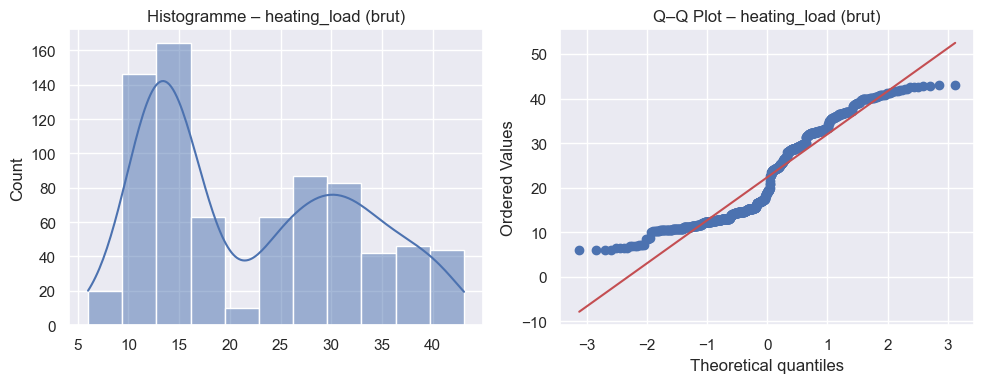

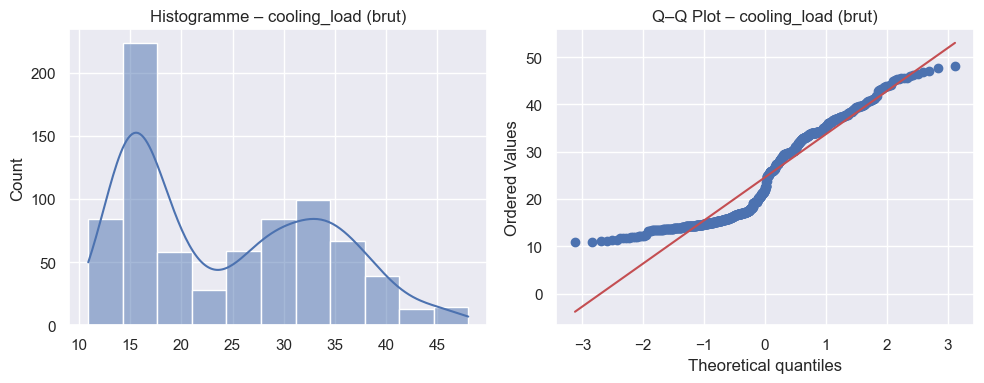

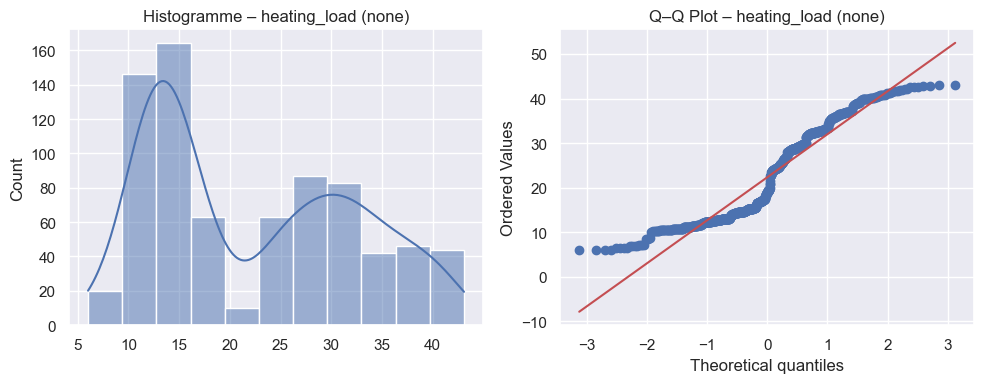

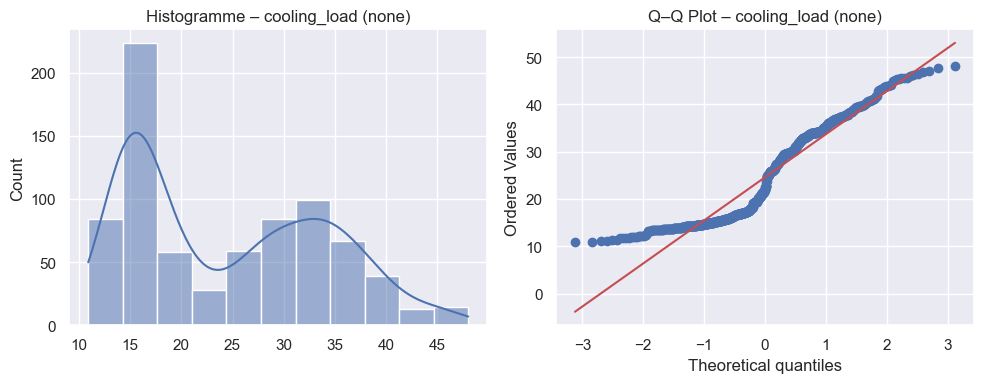

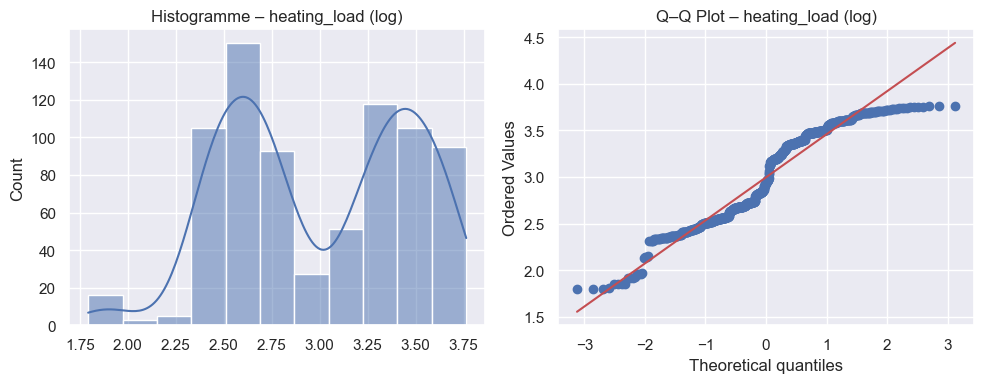

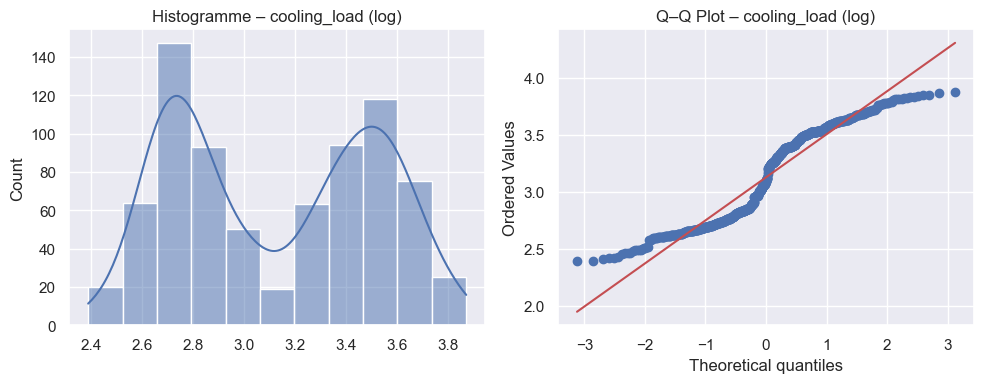

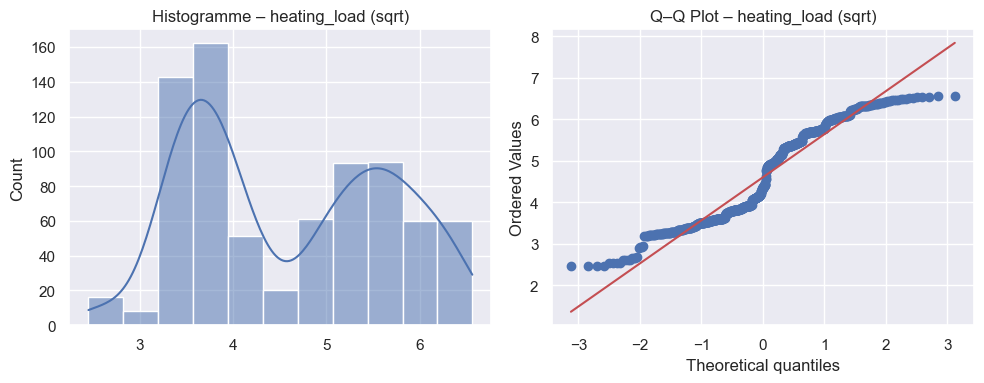

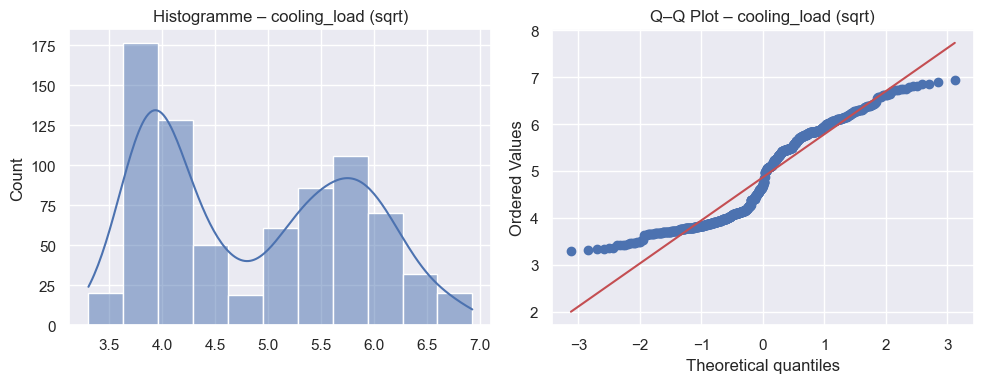

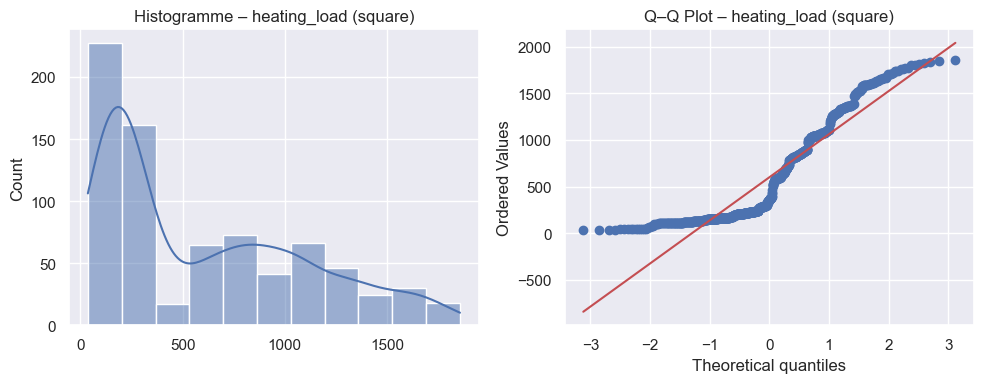

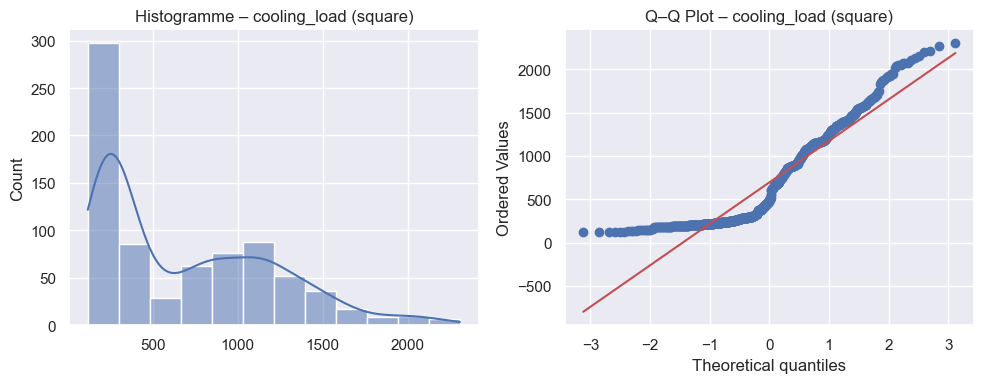

In [141]:
def plot_label_eda(y, name):
    fig, axes = plt.subplots(1,2,figsize=(10,4))
    sns.histplot(y, kde=True, ax=axes[0]).set_title(f"Histogramme – {name}")
    probplot(y, plot=axes[1]); axes[1].set_title(f"Q–Q Plot – {name}")
    plt.tight_layout()
    print(f"{name} → skew={skew(y):.3f}, kurtosis={kurtosis(y):.3f}\n")

# distributions brutes
plot_label_eda(y_heating, "heating_load (brut)")
plot_label_eda(y_cooling, "cooling_load (brut)")

# transforms simples
# transforms simples pour y
simple_label_transforms = {
    name: FunctionTransformer(
        func=lambda y, f=func: f(y).reshape(-1,1),
        inverse_func=lambda y, inv=inv: inv(y).reshape(-1),
        validate=False,
        check_inverse=False
    )
    for name, (func, inv) in {
        'none':   (lambda y: y,             lambda y: y),
        'log':    (np.log,                  np.exp),
        'sqrt':   (np.sqrt,                 np.square),
        'square': (lambda y: y**2,          np.sqrt),
    }.items()
}

for name, tf in simple_label_transforms.items():
    print(f"--- {name} (heating) ---")
    plot_label_eda(tf.transform(y_heating).ravel(), f"heating_load ({name})")
    print(f"--- {name} (cooling) ---")
    plot_label_eda(tf.transform(y_cooling).ravel(), f"cooling_load ({name})")

# estimation λ pour Box–Cox et Yeo–Johnson
for method in ('box-cox','yeo-johnson'):
    pt = PowerTransformer(method=method, standardize=False)
    l_h = pt.fit(y_heating.reshape(-1,1)).lambdas_[0]
    l_c = pt.fit(y_cooling.reshape(-1,1)).lambdas_[0]
    print(f"{method}: λ heating={l_h:.3f}, λ cooling={l_c:.3f}")

## 11 : Sélection automatique des transforms de features

In [144]:
transform_funcs = {
    'identity': lambda x: x,
    'log':      np.log,
    'sqrt':     np.sqrt,
    'square':   lambda x: x**2,
}

records = []
feature_transform_map = {}

for feat in numeric_feats:
    x = df_sel[feat].values
    corr_h0 = pearsonr(x, y_heating)[0]
    corr_c0 = pearsonr(x, y_cooling)[0]
    selected = ['identity']
    
    for name, func in transform_funcs.items():
        if name == 'identity':
            continue
        # Vérifier le domaine
        if name == 'log' and np.any(x <= 0):
            continue
        if name == 'sqrt' and np.any(x < 0):
            continue
        
        # Appliquer la transformation et filtrer inf/nan
        xt = func(x)
        valid = np.isfinite(xt)
        if not np.all(valid):
            continue
        
        # Calcul de corrélations
        corr_h = pearsonr(xt, y_heating)[0]
        corr_c = pearsonr(xt, y_cooling)[0]
        
        # Critère d’amélioration
        if abs(corr_h) > abs(corr_h0) + 0.01 or abs(corr_c) > abs(corr_c0) + 0.01:
            selected.append(name)
        
        records.append({
            'feature':  feat,
            'transform': name,
            'skew':      skew(x),
            'kurtosis':  kurtosis(x),
            'corr_h0':   corr_h0,
            'corr_h':    corr_h,
            'corr_c0':   corr_c0,
            'corr_c':    corr_c
        })
    
    feature_transform_map[feat] = selected

dist_df = pd.DataFrame(records)
display(dist_df)

print("Transforms retenues par feature :")
from pprint import pprint
pprint(feature_transform_map)

,feature,transform,skew,kurtosis,corr_h0,corr_h,corr_c0,corr_c
0,f_relative_compactness,log,0.494544,-0.709778,0.622272,0.637298,0.634339,0.650995
1,f_relative_compactness,sqrt,0.494544,-0.709778,0.622272,0.630371,0.634339,0.643260
2,f_relative_compactness,square,0.494544,-0.709778,0.622272,0.602807,0.634339,0.613201
3,f_wall_area,log,0.532375,0.108033,0.455671,0.461720,0.427117,0.435521
4,f_wall_area,sqrt,0.532375,0.108033,0.455671,0.458929,0.427117,0.431518
5,f_wall_area,square,0.532375,0.108033,0.455671,0.448047,0.427117,0.417467
6,f_overall_height,log,0.000000,-2.000000,0.889430,0.889430,0.895785,0.895785
7,f_overall_height,sqrt,0.000000,-2.000000,0.889430,0.889430,0.895785,0.895785
8,f_overall_height,square,0.000000,-2.000000,0.889430,0.889430,0.895785,0.895785
9,f_glazing_area,sqrt,-0.060136,-1.326804,0.269842,0.283940,0.207505,0.210698


Transforms retenues par feature :
{'f_glazing_area': ['identity', 'sqrt'],
 'f_overall_height': ['identity'],
 'f_relative_compactness': ['identity', 'log'],
 'f_wall_area': ['identity']}


## 12 : Construction de preproc_auto et preproc_full

In [147]:
def build_preproc_auto(feature_transform_map, cat_feats):
    transformers = []
    for feat, trans_list in feature_transform_map.items():
        for name in trans_list:
            transformers.append((
                f"{feat}_{name}",            # un seul underscore
                Pipeline([
                    ('op',    FunctionTransformer(transform_funcs[name], validate=False)),
                    ('scale', StandardScaler())
                ]),
                [feat]
            ))
    if cat_feats:
        transformers.append((
            'cat', OneHotEncoder(drop='first', sparse_output=False),
            cat_feats
        ))
    return ColumnTransformer(transformers, remainder='drop')

# Reconstruisez ensuite :
preproc_auto = build_preproc_auto(feature_transform_map, cat_feats)

In [149]:
# 1) Détecter dynamiquement les transformations valides en filtrant domaine
feature_transform_map_full = {}
for feat in numeric_feats:
    x = df_sel[feat].values
    valid_trans = []
    for name, func in transform_funcs.items():
        # – On ne teste pas log sur x ≤ 0
        if name == 'log'  and np.any(x <= 0):   continue
        # – On ne teste pas sqrt sur x < 0
        if name == 'sqrt' and np.any(x <  0):   continue

        # Suppression des warnings lors de l'application
        with np.errstate(divide='ignore', invalid='ignore'):
            xt = func(x)
        # Conserver si *aucun* inf/nan
        if np.all(np.isfinite(xt)):
            valid_trans.append(name)

    # Garantir au moins l'identité
    feature_transform_map_full[feat] = valid_trans or ['identity']

# 2) Construire le ColumnTransformer
def build_preproc_full(ft_map, cat_feats):
    transformers = []
    for feat, trans_list in ft_map.items():
        for name in trans_list:
            transformers.append((
                f"{feat}_{name}",
                Pipeline([
                    ('op',    FunctionTransformer(transform_funcs[name], validate=False)),
                    ('scale', StandardScaler())
                ]),
                [feat]
            ))
    if cat_feats:
        transformers.append((
            'cat',
            OneHotEncoder(drop='first', sparse_output=False),
            cat_feats
        ))
    return ColumnTransformer(transformers, remainder='drop')

preproc_full = build_preproc_full(feature_transform_map_full, cat_feats)

## 13 : Nested CV – choix transform y + stepwise

In [152]:
# 1) Les deux seuls stepwise supportés ici
inner_cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=0)
sfs_fw   = SequentialFeatureSelector(
    LinearRegression(), direction='forward',  cv=inner_cv, n_features_to_select='auto')
sfs_bw   = SequentialFeatureSelector(
    LinearRegression(), direction='backward', cv=inner_cv, n_features_to_select='auto')

# 2) Transformations de y (incluant Box–Cox & Yeo–Johnson)
label_transforms = {
    **simple_label_transforms,
    'box-cox':     PowerTransformer(method='box-cox',    standardize=False),
    'yeo-johnson': PowerTransformer(method='yeo-johnson',standardize=False),
}

# 3) Nested CV (outer)
outer_cv    = RepeatedKFold(n_splits=5, n_repeats=3, random_state=0)
rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

best_results = {}
for label in ['l_heating_load','l_cooling_load']:
    X = df_sel[numeric_feats + cat_feats]
    y = df_sel[label].values
    best = {'rmse': np.inf}

    for t_name, transformer in label_transforms.items():
        for sel_name, selector in (('forward', sfs_fw), ('backward', sfs_bw)):
            # construire le TTR avec stepwise forward ou backward
            ttr = TransformedTargetRegressor(
                regressor=Pipeline([
                    ('preproc',  preproc_full),
                    ('selector', selector),
                    ('reg', RidgeCV(alphas=[0.01,0.1,1,10,100], cv=inner_cv))
                ]),
                transformer=transformer,
                check_inverse=False
            )
            # évaluer RMSE sur l'échelle d'origine
            scores = cross_val_score(
                ttr, X, y,
                scoring=rmse_scorer,
                cv=outer_cv, n_jobs=-1
            )
            rmse_cv = -scores.mean()
            print(f"{label} / y={t_name:<10s} / sel={sel_name:<8s} → RMSE={rmse_cv:.4f}")
            if rmse_cv < best['rmse']:
                best.update(
                    rmse=rmse_cv,
                    transfo=t_name,
                    stepwise=sel_name,
                    ttr=ttr
                )

    print(f"→ Meilleur pour {label}: transfo={best['transfo']}, "
          f"stepwise={best['stepwise']} (RMSE={best['rmse']:.4f})\n")
    best_results[label] = best

l_heating_load / y=none       / sel=forward  → RMSE=2.5910
l_heating_load / y=none       / sel=backward → RMSE=2.6204
l_heating_load / y=log        / sel=forward  → RMSE=2.5369
l_heating_load / y=log        / sel=backward → RMSE=2.6075
l_heating_load / y=sqrt       / sel=forward  → RMSE=2.4792
l_heating_load / y=sqrt       / sel=backward → RMSE=2.5250
l_heating_load / y=square     / sel=forward  → RMSE=nan
l_heating_load / y=square     / sel=backward → RMSE=nan
l_heating_load / y=box-cox    / sel=forward  → RMSE=2.5371
l_heating_load / y=box-cox    / sel=backward → RMSE=2.5623
l_heating_load / y=yeo-johnson / sel=forward  → RMSE=2.5376
l_heating_load / y=yeo-johnson / sel=backward → RMSE=2.5607
→ Meilleur pour l_heating_load: transfo=sqrt, stepwise=forward (RMSE=2.4792)

l_cooling_load / y=none       / sel=forward  → RMSE=3.0508
l_cooling_load / y=none       / sel=backward → RMSE=2.9648
l_cooling_load / y=log        / sel=forward  → RMSE=2.8870
l_cooling_load / y=log        / sel=backw

In [159]:
# Transformer pour garantir un DataFrame en entrée (résout l'erreur string cols sur numpy)
to_df = FunctionTransformer(
    func=lambda X: pd.DataFrame(X, columns=numeric_feats+cat_feats),
    validate=False
)

# Inner CV pour stepwise et régularisation
inner_cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=0)
sfs_fw   = SequentialFeatureSelector(
    RidgeCV(alphas=[0.01,0.1,1,10], cv=inner_cv),
    direction='forward', cv=inner_cv,
    n_features_to_select='auto'
)
# Outer CV
outer_cv    = RepeatedKFold(n_splits=5, n_repeats=3, random_state=0)
rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

# Pour chaque label, comparer RidgeCV, Huber, Bagging
results = {}
for label in ['l_heating_load', 'l_cooling_load']:
    X = df_sel[numeric_feats + cat_feats]
    y = df_sel[label].values
    best = {'rmse': np.inf, 'model': None}

    # 1) Pipeline RidgeCV
    pipe_ridge = Pipeline([
        ('to_df',    to_df),
        ('preproc',  preproc_full),
        ('selector', sfs_fw),
        ('reg',      RidgeCV(alphas=[0.01,0.1,1,10], cv=inner_cv))
    ])
    # 2) Pipeline Huber
    pipe_huber = Pipeline([
        ('to_df',    to_df),
        ('preproc',  preproc_full),
        ('selector', sfs_fw),
        ('reg',      HuberRegressor(alpha=1.0))
    ])
    # 3) Bagging sur Ridge
    bagging = BaggingRegressor(
        estimator=Pipeline([
            ('to_df',    to_df),
            ('preproc',  preproc_full),
            ('selector', sfs_fw),
            ('reg',      RidgeCV(alphas=[0.01,0.1,1,10], cv=inner_cv))
        ]),
        n_estimators=30,
        max_samples=0.8,
        random_state=0,
        n_jobs=-1
    )

    for name, reg in [('ridge', pipe_ridge), ('huber', pipe_huber), ('bagging', bagging)]:
        # TTR wrapper pour y transformé
        ttr = TransformedTargetRegressor(
            regressor=reg,
            transformer=label_transforms[best_results[label]['transfo']],
            check_inverse=False
        )
        scores = cross_val_score(ttr, X, y,
                                 scoring=rmse_scorer,
                                 cv=outer_cv, n_jobs=-1)
        rmse_cv = -scores.mean()
        print(f"{label} / model={name:<7s} → RMSE CV={rmse_cv:.4f}")
        if rmse_cv < best['rmse']:
            best.update(rmse=rmse_cv, model=name, model_obj=ttr)

    print(f"→ Meilleur pour {label}: model={best['model']}, RMSE={best['rmse']:.4f}")
    results[label] = best

l_heating_load / model=ridge   → RMSE CV=2.4396
l_heating_load / model=huber   → RMSE CV=2.6813
l_heating_load / model=bagging → RMSE CV=2.4785
→ Meilleur pour l_heating_load: model=ridge, RMSE=2.4396
l_cooling_load / model=ridge   → RMSE CV=2.8799
l_cooling_load / model=huber   → RMSE CV=3.0932
l_cooling_load / model=bagging → RMSE CV=2.9036
→ Meilleur pour l_cooling_load: model=ridge, RMSE=2.8799


## 14 : Entraînement final & diagnostics

In [130]:
def interpret_shapiro(p):
    return "normalité plausible (p ≥ 0.05)" if p >= 0.05 else "rejet de la normalité (p < 0.05)"

def interpret_durbin(dw):
    return "pas d’autocorrélation (1.5 < DW < 2.5)" if 1.5 < dw < 2.5 else "autocorrélation possible (DW en dehors de [1.5,2.5])"

def interpret_bp(p):
    return "homoscédasticité plausible (p ≥ 0.05)" if p >= 0.05 else "hétéroscédasticité détectée (p < 0.05)"

for label, info in best_results.items():
    X = df_sel[numeric_feats + cat_feats]
    y_true = df_sel[label].values

    # ► Entraînement final sur tout
    ttr_final = info['ttr'].fit(X, y_true)
    # ► Prédiction en échelle d'origine
    y_pred = ttr_final.predict(X)

    # ► Résidus
    resid = y_true - y_pred

    # ► Tests statistiques
    W, p_sh = shapiro(resid)
    dw      = durbin_watson(resid)
    Xc      = sm.add_constant(X, has_constant='add')
    lm, lm_p, _, _ = het_breuschpagan(resid, Xc)

    # ► RMSE sur échelle originale
    rmse_orig = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n### Modèle final pour {label} ###")
    print(f"• RMSE (échelle d’origine) : {rmse_orig:.4f}")

    print("\n— Test de normalité des résidus (Shapiro–Wilk) —")
    print(f"  W = {W:.4f}, p = {p_sh:.4g} → {interpret_shapiro(p_sh)}")

    print("\n— Test d’autocorrélation (Durbin–Watson) —")
    print(f"  DW = {dw:.4f} → {interpret_durbin(dw)}")

    print("\n— Test d’homoscédasticité (Breusch–Pagan) —")
    print(f"  LM p = {lm_p:.4g} → {interpret_bp(lm_p)}")

    # ► Extraction des noms parlants
    preproc_fitted = ttr_final.regressor_.named_steps['preproc']
    feat_names = []
    for name, transformer, cols in preproc_fitted.transformers_:
        if name == 'cat':
            enc = transformer
            for col, cats in zip(cols, enc.categories_):
                for cat in cats[1:]:
                    feat_names.append(f"{col}_{cat}")
        else:
            for _ in cols:
                feat_names.append(name)

    selector = ttr_final.regressor_.named_steps['selector']
    mask     = selector.get_support()
    selected_features = [f for f, m in zip(feat_names, mask) if m]

    print("\nFeatures retenues :", selected_features)


### Modèle final pour l_heating_load ###
• RMSE (échelle d’origine) : 2.4063

— Test de normalité des résidus (Shapiro–Wilk) —
  W = 0.9110, p = 8.763e-21 → rejet de la normalité (p < 0.05)

— Test d’autocorrélation (Durbin–Watson) —
  DW = 0.7830 → autocorrélation possible (DW en dehors de [1.5,2.5])

— Test d’homoscédasticité (Breusch–Pagan) —
  LM p = 4.747e-74 → hétéroscédasticité détectée (p < 0.05)

Features retenues : ['f_relative_compactness_log', 'f_relative_compactness_sqrt', 'f_relative_compactness_square', 'f_wall_area_identity', 'f_wall_area_log', 'f_wall_area_sqrt', 'f_wall_area_square', 'f_overall_height_identity', 'f_glazing_area_sqrt']

### Modèle final pour l_cooling_load ###
• RMSE (échelle d’origine) : 2.8539

— Test de normalité des résidus (Shapiro–Wilk) —
  W = 0.9146, p = 2.231e-20 → rejet de la normalité (p < 0.05)

— Test d’autocorrélation (Durbin–Watson) —
  DW = 1.2107 → autocorrélation possible (DW en dehors de [1.5,2.5])

— Test d’homoscédasticité (Breusc

In [163]:
for label, info in results.items():
    X = df_sel[numeric_feats + cat_feats]
    y_true = df_sel[label].values

    # Fit du meilleur modèle
    ttr_final = info['model_obj'].fit(X, y_true)
    y_pred    = ttr_final.predict(X)
    resid     = y_true - y_pred

    # Tests
    W, p_sh = shapiro(resid)
    dw      = durbin_watson(resid)
    Xc      = sm.add_constant(X, has_constant='add')
    lm, lm_p, _, _ = het_breuschpagan(resid, Xc)
    rmse_orig = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"### Final pour {label} ({info['model']}) ###")
    print(f"RMSE (origine) : {rmse_orig:.4f}")
    print(f"Shapiro–Wilk W={W:.4f}, p={p_sh:.4g} -> {'normalité OK' if p_sh>=0.05 else 'normalité KO'}")
    print(f"Durbin–Watson DW={dw:.4f} -> {'pas d’autocorr.' if 1.5<dw<2.5 else 'autocorr. KO'}")
    print(f"Breusch–Pagan LM p={lm_p:.4g} -> {'homoscédast.' if lm_p>=0.05 else 'hétéroscédast. KO'}")

    # Features parlantes
    preproc_fitted = ttr_final.regressor_.named_steps.get('preproc', preproc_full)
    feat_names = []
    for name, transformer, cols in preproc_fitted.transformers_:
        if name == 'cat':
            enc = transformer
            for col, cats in zip(cols, enc.categories_):
                for cat in cats[1:]:
                    feat_names.append(f"{col}_{cat}")
        else:
            for _ in cols:
                feat_names.append(name)
    mask = ttr_final.regressor_.named_steps['selector'].get_support()
    selected = [f for f, m in zip(feat_names, mask) if m]
    print('Features retenues :', selected)


### Final pour l_heating_load (ridge) ###
RMSE (origine) : 2.4031
Shapiro–Wilk W=0.9014, p=8.019e-22 -> normalité KO
Durbin–Watson DW=0.7976 -> autocorr. KO
Breusch–Pagan LM p=5.201e-77 -> hétéroscédast. KO
Features retenues : ['f_relative_compactness_log', 'f_relative_compactness_square', 'f_wall_area_identity', 'f_wall_area_log', 'f_wall_area_square', 'f_overall_height_identity', 'f_glazing_area_identity', 'f_glazing_area_sqrt', 'f_glazing_area_square']
### Final pour l_cooling_load (ridge) ###
RMSE (origine) : 2.8427
Shapiro–Wilk W=0.9162, p=3.429e-20 -> normalité KO
Durbin–Watson DW=1.2146 -> autocorr. KO
Breusch–Pagan LM p=3.137e-41 -> hétéroscédast. KO
Features retenues : ['f_relative_compactness_identity', 'f_relative_compactness_log', 'f_relative_compactness_square', 'f_wall_area_identity', 'f_wall_area_log', 'f_wall_area_sqrt', 'f_wall_area_square', 'f_overall_height_identity', 'f_glazing_area_sqrt']
